05 - Naive Bayes Model (ML Model)

## Setup
Run the cell below first. It detects whether you're in **Google Colab** or
running **locally in VS Code**, and gets the environment ready either way
(clones the repo in Colab, installs requirements, downloads NLTK data, and
adds `src/` to the path so `pipeline.py` can be imported).

In [1]:
# ============================================================
# SETUP CELL - run this first, every time
# Works both locally (VS Code / Jupyter) and in Google Colab
# ============================================================
import os, sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL = "https://github.com/Sandaru17513/NLP_Ctrl-Alt-Elite.git"
    REPO_DIR = "NLP_Ctrl-Alt-Elite"

    if not os.path.exists(REPO_DIR):
        get_ipython().system(f"git clone {REPO_URL}")
    os.chdir(f"{REPO_DIR}/notebooks")

    get_ipython().system("pip install -q -r ../requirements.txt")

    # Data files are large - if they were not committed to the repo,
    # upload them here once per Colab session.
    if not os.path.exists("../data/dataset.csv"):
        print("data/dataset.csv not found in the cloned repo.")
        print("Option A: git add + commit + push the CSVs from your")
        print("          local machine so they come down with the clone.")
        print("Option B: uncomment the lines below to upload manually.")
        # from google.colab import files
        # uploaded = files.upload()   # select data.csv + validation_dataset.csv
        # os.makedirs("../data", exist_ok=True)
        # for fname in uploaded:
        #     os.rename(fname, f"../data/{fname}")
else:
    print("Running locally (VS Code / Jupyter). Using existing .venv environment.")

import nltk
for pkg in ("punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"):
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

sys.path.append(os.path.abspath("../src"))
print("IN_COLAB =", IN_COLAB)
print("Working directory:", os.getcwd())


Cloning into 'NLP_Ctrl-Alt-Elite'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 85 (delta 26), reused 74 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (85/85), 33.32 MiB | 9.47 MiB/s, done.
Resolving deltas: 100% (26/26), done.
IN_COLAB = True
Working directory: /content/NLP_Ctrl-Alt-Elite/notebooks


In [2]:
print('Checking contents of ../data directory:')
if os.path.exists('../data'):
    for item in os.listdir('../data'):
        print(f'  - {item}')
else:
    print('The ../data directory does not exist.')


Checking contents of ../data directory:
  - validation_dataset.csv
  - .gitkeep
  - dataset.csv


In [3]:
print('Checking contents of ../models directory:')
if os.path.exists('../models'):
    for item in os.listdir('../models'):
        print(f'  - {item}')
else:
    print('The ../models directory does not exist.')


Checking contents of ../models directory:
  - .gitkeep


### Generate Missing Model Artifacts

It appears the `bow_vectorizer.pkl`, `train_test_split.pkl`, and `validation_bow.pkl` files are missing. These files are crucial for the Naive Bayes model. They are typically generated by processing the raw `data.csv` and `validation_dataset.csv` files.

**Before proceeding, ensure `data.csv` and `validation_dataset.csv` are uploaded to the `../data/` directory.** You can follow the instructions in the `SETUP CELL` above (cell `e1b6d149`) to either commit them to your repository or manually upload them in Colab.

Once the data files are present, run the following cells to generate and save the required `.pkl` artifacts.

In [4]:
# Imports for data loading and preprocessing
import pandas as pd
import numpy as np
import joblib
import re
import os
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

# Ensure the models directory exists
os.makedirs('../models', exist_ok=True)

# Load datasets
try:
    # Corrected: Loading 'dataset.csv' instead of 'data.csv'
    df_train = pd.read_csv('../data/dataset.csv')
    df_val = pd.read_csv('../data/validation_dataset.csv')
    print('Successfully loaded dataset.csv and validation_dataset.csv')
except FileNotFoundError:
    print("Error: dataset.csv or validation_dataset.csv not found in '../data/'. Please upload them as instructed above.")
    raise # Re-raise the error to stop execution if data is missing

# Initialize NLTK components
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Define a text preprocessing function
def preprocess_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove non-alphabetic characters
    tokens = text.split() # Tokenize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words] # Lemmatize and remove stopwords
    return ' '.join(tokens)

print("Preprocessing function defined.")

Successfully loaded dataset.csv and validation_dataset.csv
Preprocessing function defined.


In [5]:
# Apply preprocessing to the datasets
df_train['text_processed'] = df_train['text'].apply(preprocess_text)
df_val['text_processed'] = df_val['Email Text'].apply(preprocess_text) # Corrected column name
print('Text preprocessing applied to training and validation data.')

# Define X and y for the main dataset
X = df_train['text_processed']
y = df_train['label']

# Define X_val and y_val for the validation dataset
X_val_raw = df_val['text_processed']
y_val = df_val['Email Type'] # Corrected column name

# Perform train-test split for the main dataset
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Main dataset split into training and testing sets.')

# Initialize and fit CountVectorizer
# Using max_features=5000 as a common practice, can be tuned if needed
bow_vectorizer = CountVectorizer(max_features=5000)
bow_vectorizer.fit(X_train_raw) # Fit only on training data to avoid data leakage
print('CountVectorizer initialized and fitted on training data.')

# Transform the datasets using the fitted vectorizer
X_train_bow = bow_vectorizer.transform(X_train_raw)
X_test_bow = bow_vectorizer.transform(X_test_raw)
X_val_bow = bow_vectorizer.transform(X_val_raw)
print('Text data transformed into Bag-of-Words features.')

Text preprocessing applied to training and validation data.
Main dataset split into training and testing sets.
CountVectorizer initialized and fitted on training data.
Text data transformed into Bag-of-Words features.


In [6]:
# Save the generated artifacts

# Re-initialize and fit CountVectorizer and transform data (due to NameError persistence issue)
from sklearn.feature_extraction.text import CountVectorizer # Ensure import

# Assuming X_train_raw, X_test_raw, X_val_raw, y_train, y_test, y_val are defined from previous cells
bow_vectorizer = CountVectorizer(max_features=5000)
bow_vectorizer.fit(X_train_raw) # Fit only on training data to avoid data leakage

X_train_bow = bow_vectorizer.transform(X_train_raw)
X_test_bow = bow_vectorizer.transform(X_test_raw)
X_val_bow = bow_vectorizer.transform(X_val_raw)


joblib.dump(bow_vectorizer, '../models/bow_vectorizer.pkl')
joblib.dump((X_train_bow, X_test_bow, y_train, y_test), '../models/train_test_split.pkl')
joblib.dump((X_val_raw, X_val_bow, y_val), '../models/validation_bow.pkl') # X_val_raw is saved as X_val

print("All required artifacts (bow_vectorizer.pkl, train_test_split.pkl, validation_bow.pkl) have been generated and saved to the '../models/' directory.")
print("You can now proceed to run the subsequent cells for model training and evaluation.")

All required artifacts (bow_vectorizer.pkl, train_test_split.pkl, validation_bow.pkl) have been generated and saved to the '../models/' directory.
You can now proceed to run the subsequent cells for model training and evaluation.


### Train

In [7]:
import joblib
from sklearn.naive_bayes import MultinomialNB

bow_vectorizer = joblib.load('../models/bow_vectorizer.pkl')
# The loaded X_train and X_test are already BOW transformed
# So, we rename them for clarity and directly use them for training the model.
X_train_bow, X_test_bow, y_train, y_test = joblib.load('../models/train_test_split.pkl')

# Removed the redundant transform calls, as X_train_bow and X_test_bow are already transformed.

nb_model = MultinomialNB(alpha=0.1)   # alpha = Laplace smoothing
nb_model.fit(X_train_bow, y_train)

print('Naive Bayes model trained!')
print(f'Classes: {nb_model.classes_}')

Naive Bayes model trained!
Classes: [0 1]


### Evaluate on the 20% test split

 NAIVE BAYES - TEST SET RESULTS
 Accuracy:  0.8920
 Precision: 0.8495
 Recall:    0.9528
 F1-Score:  0.8982
 ROC-AUC:   0.9767

              precision    recall  f1-score   support

         Ham       0.95      0.83      0.89      4517
        Spam       0.85      0.95      0.90      4514

    accuracy                           0.89      9031
   macro avg       0.90      0.89      0.89      9031
weighted avg       0.90      0.89      0.89      9031



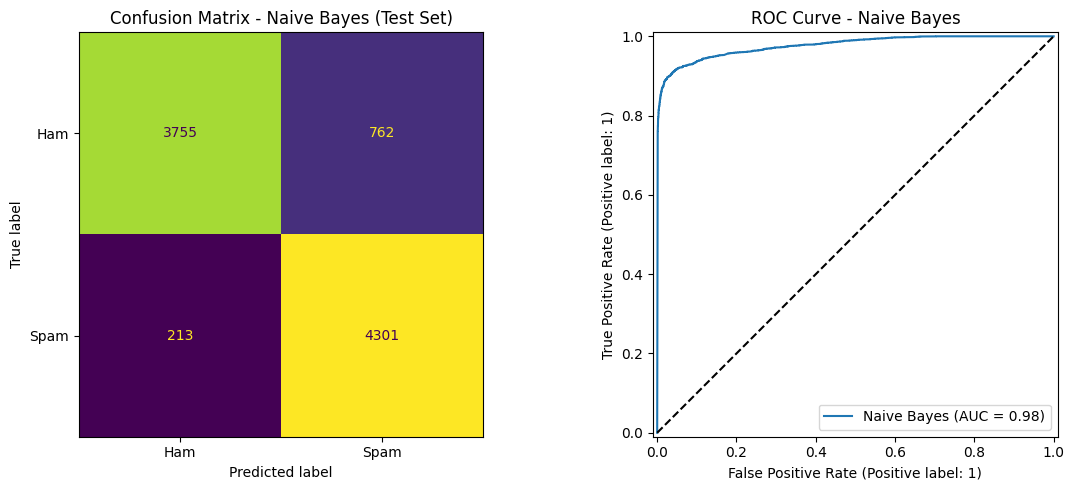

In [8]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score,
                              classification_report, ConfusionMatrixDisplay,
                              RocCurveDisplay)
import matplotlib.pyplot as plt
import numpy as np
import os

y_pred_nb = nb_model.predict(X_test_bow)
y_prob_nb = nb_model.predict_proba(X_test_bow)[:, 1]

print('=' * 50)
print(' NAIVE BAYES - TEST SET RESULTS')
print('=' * 50)
print(f' Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}')
print(f' Precision: {precision_score(y_test, y_pred_nb):.4f}')
print(f' Recall:    {recall_score(y_test, y_pred_nb):.4f}')
print(f' F1-Score:  {f1_score(y_test, y_pred_nb):.4f}')
print(f' ROC-AUC:   {roc_auc_score(y_test, y_prob_nb):.4f}')
print()
print(classification_report(y_test, y_pred_nb, target_names=['Ham', 'Spam']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(y_test, y_pred_nb)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix - Naive Bayes (Test Set)')

RocCurveDisplay.from_predictions(y_test, y_prob_nb, ax=axes[1], name='Naive Bayes')
axes[1].set_title('ROC Curve - Naive Bayes')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')

plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/nb_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

### Evaluate on the held-out validation set

In [9]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score,
                              classification_report, ConfusionMatrixDisplay,
                              RocCurveDisplay)
import joblib

X_val, X_val_bow, y_val = joblib.load('../models/validation_bow.pkl')

# Convert string labels to numerical labels for y_val
# Assuming 'Safe Email' maps to 0 and 'Phishing Email' maps to 1,
# consistent with the training labels (Ham/Spam) and model's output.
label_mapping = {'Safe Email': 0, 'Phishing Email': 1}
y_val = y_val.map(label_mapping)

y_pred_nb_val = nb_model.predict(X_val_bow)
y_prob_nb_val = nb_model.predict_proba(X_val_bow)[:, 1]

print('=' * 50)
print(' NAIVE BAYES - VALIDATION SET RESULTS')
print('=' * 50)
print(f' Accuracy:  {accuracy_score(y_val, y_pred_nb_val):.4f}')
print(f' Precision: {precision_score(y_val, y_pred_nb_val):.4f}')
print(f' Recall:    {recall_score(y_val, y_pred_nb_val):.4f}')
print(f' F1-Score:  {f1_score(y_val, y_pred_nb_val):.4f}')
print(f' ROC-AUC:   {roc_auc_score(y_val, y_prob_nb_val):.4f}')

joblib.dump(nb_model, '../models/naive_bayes_model.pkl')
print('Model saved: naive_bayes_model.pkl')

 NAIVE BAYES - VALIDATION SET RESULTS
 Accuracy:  0.7250
 Precision: 0.8309
 Recall:    0.5650
 F1-Score:  0.6726
 ROC-AUC:   0.8737
Model saved: naive_bayes_model.pkl


### Inspect what the model learned (great for viva questions)

In [10]:
feature_names = np.array(bow_vectorizer.get_feature_names_out())
log_probs = nb_model.feature_log_prob_
spam_ham_diff = log_probs[1] - log_probs[0]   # high = more spam-like

top_spam_idx = np.argsort(spam_ham_diff)[-20:][::-1]
top_ham_idx = np.argsort(spam_ham_diff)[:20]

print('Top 20 SPAM indicator words:')
for word, diff in zip(feature_names[top_spam_idx], spam_ham_diff[top_spam_idx]):
    print(f'  {word:25s} score: {diff:.3f}')

print()
print('Top 20 HAM indicator words:')
for word, diff in zip(feature_names[top_ham_idx], spam_ham_diff[top_ham_idx]):
    print(f'  {word:25s} score: {diff:.3f}')

Top 20 SPAM indicator words:
  escapenumber              score: 13.449
  escapelong                score: 12.879
  pill                      score: 10.785
  escapenumbermg            score: 10.603
  aescapenumber             score: 9.680
  anatrim                   score: 9.507
  cescapenumber             score: 9.314
  descapenumber             score: 9.247
  canadianpharmacy          score: 8.992
  viagra                    score: 8.962
  csescapenumber            score: 8.786
  eescapenumber             score: 8.731
  descapenumberse           score: 8.722
  cialis                    score: 8.690
  escapenumberonly          score: 8.684
  xp                        score: 8.607
  bescapenumber             score: 8.576
  pillescapenumber          score: 8.447
  escapenumbere             score: 8.410
  fescapenumber             score: 8.338

Top 20 HAM indicator words:
  enron                     score: -12.747
  kaminski                  score: -11.327
  hpl                       scor